# CME538 - Introduction to Data Science

## Tutorial 9 - PCA and K-means Clustering

In this tutorial, we will explore two important unsupervised learning techniques:

- **K-means clustering**: grouping observations based on their similarity
- **Principal Component Analysis (PCA)**: creating a lower-dimensional representation of a dataset

We will use the Palmer Penguins dataset throughout the tutorial.

### Learning objectives

By the end of this tutorial, you should be able to:

1. Explain the basic idea behind K-means clustering.
2. Apply feature scaling before distance-based algorithms.
3. Explain the intuition behind PCA.
4. Use PCA to reduce the dimensionality of a dataset.
5. Interpret explained variance and PCA loadings.
6. Apply K-means clustering to PCA-transformed data.
7. Use the elbow method and silhouette score to help choose the number of clusters.

### Tutorial roadmap

We will follow this workflow:

**Data → EDA → K-means → Scaling → PCA → K-means + PCA → Choosing the number of clusters**

The goal is not to build a complicated model, but to understand the intuition behind these methods and see how they can be used together.

# 1. Setup

First, we import the packages that we will use throughout the tutorial.

In [ ]:
import warnings

# Keep the tutorial output focused on results rather than library warnings.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# Use a consistent, readable style for every plot in the tutorial.
sns.set_theme(style="whitegrid", context="notebook")

# Fix the random seed so repeated runs produce the same K-means solution.
RANDOM_STATE = 42

# 2. Reading the data

The Palmer Penguins dataset contains measurements for three penguin species:

- Adelie
- Chinstrap
- Gentoo

The dataset contains measurements such as bill length, bill depth, flipper length, and body mass.

For this tutorial, we will use the numerical measurements as our features.

> **Important:** We will not give the penguin species to K-means. This is an **unsupervised learning** problem, so the algorithm will try to discover groups without using the species labels.

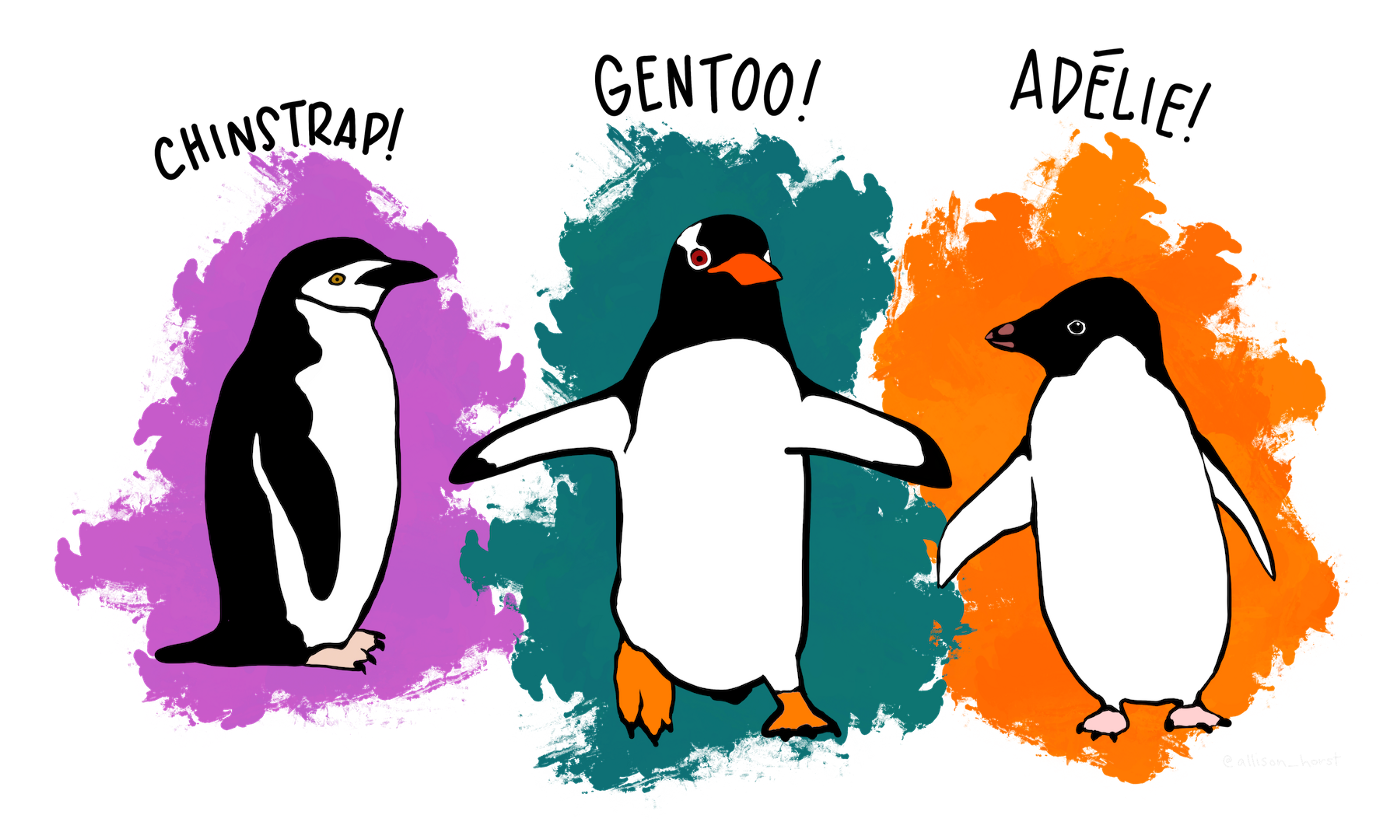

A simple image showing the three penguin species can help provide context for the dataset.

This image is optional; the tutorial can work without it.

In [ ]:
# TODO: Load "PalmerPenguins.csv" into a DataFrame called `penguins_df`.
# Hint: use pd.read_csv(), and note the first column stores the saved row index (index_col=0).

# TODO: Display the first few rows of the dataset.

In [ ]:
# TODO: Inspect the structure of the dataset (data types, non-null counts, memory usage).
# Hint: use the .info() method.

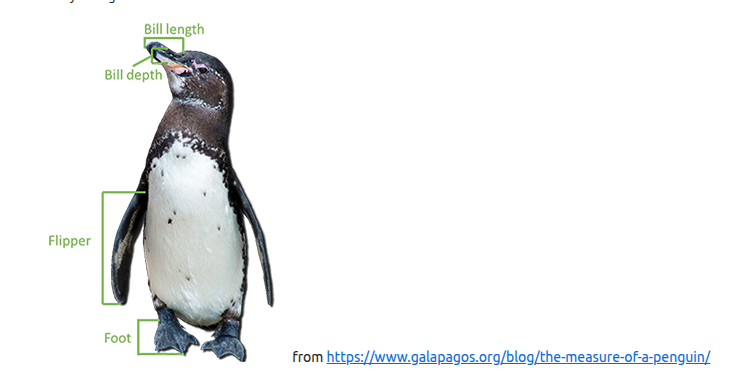

In [ ]:
# TODO: Count the number of missing values in each column.
# Hint: use .isna().sum()

We have a small number of missing observations.

For this tutorial, we will focus on the four numerical measurements and remove observations that are missing one of these measurements.

We will not try to infer missing values such as sex manually. That would introduce assumptions that are not important for our clustering task.

In [ ]:
# TODO: Define a list called `features` containing the four numerical measurements
# we will use for clustering and PCA:
# "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"

# TODO: Create `penguins_clean` by dropping rows with missing values in `features`.
# Make sure to .copy() the result so you don't modify the original DataFrame.

# TODO: Display the first few rows of penguins_clean[features] to confirm it worked.

### What about categorical variables?

Many machine-learning algorithms require numerical inputs.

If we wanted to use categorical variables such as `species`, `island`, or `sex`, we could convert them into numerical features using techniques such as **one-hot encoding**.

For this tutorial, however, we already have four numerical measurements, so we will work directly with them.

We will also keep `species` separately so that we can use it later to **interpret** our unsupervised results. It will not be used to train K-means.

# 3. A quick look at the data

Before applying an unsupervised learning algorithm, it is useful to understand the structure of the data.

We will keep the EDA short because the main focus of this tutorial is clustering and dimensionality reduction.

In [ ]:
# TODO: Create a scatterplot of flipper_length_mm (x-axis) vs body_mass_g (y-axis),
# coloured by species (hue="species").
# Remember: the species labels are shown here only for exploration —
# they are not used by any unsupervised method later in this tutorial.

# TODO: Add axis labels and a title, then show the plot.

We can already see some structure in the data.

For example, penguins with longer flippers tend to have greater body mass, and some groups appear to occupy different regions of the feature space.

This raises an interesting question:

> **Can we discover these groups without giving the algorithm the species labels?**

This is where **K-means clustering** comes in.

# 4. K-means Clustering

K-means is an **unsupervised learning algorithm** that divides observations into a chosen number of clusters.

The basic idea is:

1. Choose `k` cluster centers (centroids).
2. Assign each observation to its nearest centroid.
3. Recalculate the centroid of each cluster.
4. Repeat until the assignments stabilize.

The algorithm tries to make observations within the same cluster as similar as possible.

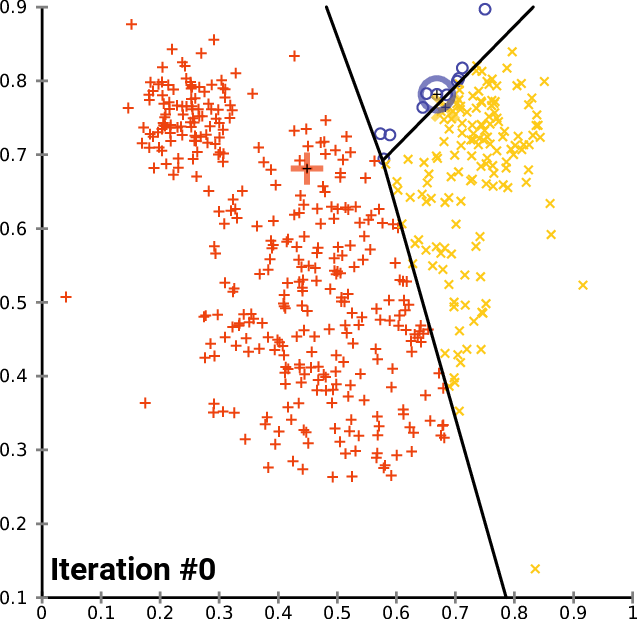

A visualization showing:

**initialize centroids → assign points → update centroids → repeat**

is particularly useful here because it makes the iterative nature of K-means much easier to understand.

### K-means and distance

K-means relies on distances between observations and cluster centroids.

This means that the scale of our features matters.

For example:

- bill depth is measured in millimetres
- body mass is measured in grams

The numerical values of body mass are much larger than the values of the other measurements.

Let's first see what happens when we apply K-means directly to the original features.

In [ ]:
# TODO: Select the numerical features into a variable `X`.

# TODO: Create a KMeans model with 3 clusters.
# Use init="k-means++", n_init=10, and random_state=RANDOM_STATE.

# TODO: Fit the model to X and store the predicted cluster label for
# each penguin in a variable called `clusters`.

# TODO: Display the first 10 cluster assignments.

In [ ]:
# TODO: Create a scatterplot of flipper_length_mm vs body_mass_g,
# colouring points by their K-means `clusters` label.
# (Note: the other two features also informed K-means, even though
# they are not shown in this 2D plot.)

# TODO: Add axis labels and a title, then show the plot.

The result gives us clusters, but there is an important issue:

**K-means uses distance, and our features are measured on very different scales.**

Body mass can have values around 3,000–6,000, while bill depth is around 13–21.

A feature with a much larger numerical scale can therefore have a disproportionate influence on the distance calculation.

This is why we commonly **standardize features before applying K-means**.

## Feature scaling

Standardization transforms each feature so that it has approximately:

- mean = 0
- standard deviation = 1

The transformation is:

$z = \frac{x - \mu}{\sigma}$
where:

- $x$ is the original value
- $\mu$ is the feature mean
- $\sigma$ is the feature standard deviation

This puts our four measurements on a comparable scale.

In [ ]:
# TODO: Create a StandardScaler.

# TODO: Fit the scaler on X and transform it into `X_scaled`.

# TODO: Convert X_scaled back into a DataFrame called `X_scaled_df`,
# using the same columns and index as X, so it's easier to inspect.

# TODO: Display the first few rows.

Now that the features are on comparable scales, we can run K-means again.

In [ ]:
# TODO: Refit K-means on the *scaled* features (X_scaled) so all four
# measurements contribute comparably to distance. Use the same
# hyperparameters as before (3 clusters, "k-means++", n_init=10,
# random_state=RANDOM_STATE). Store the model as `kmeans_scaled`.

# TODO: Fit the model and store the new cluster labels in `clusters_scaled`.

# TODO: Recreate the scatterplot (standardized flipper length vs
# standardized body mass), colouring points by `clusters_scaled`.
# Add axis labels and a title, then show the plot.

# 6. Principal Component Analysis (PCA)

We have now seen that K-means can find groups in our data.

However, our dataset has four numerical features, and some of these features are related to each other.

For example, flipper length and body mass are strongly related.

This leads to another question:

> **Can we represent the important structure in our data using fewer variables?**

This is the idea behind **Principal Component Analysis (PCA)**.

### PCA intuition

PCA creates a new set of variables called **principal components**.

Instead of working directly with:

- bill length
- bill depth
- flipper length
- body mass

PCA creates new variables such as:

- PC1
- PC2
- PC3
- PC4

Each principal component is a combination of the original features.

The components are ordered by the amount of variation they explain:

- **PC1** explains the most variation.
- **PC2** explains the next largest amount.
- PC3 explains the next largest amount.
- and so on.

Our goal is often to keep only the first few components while retaining most of the information in the original data.

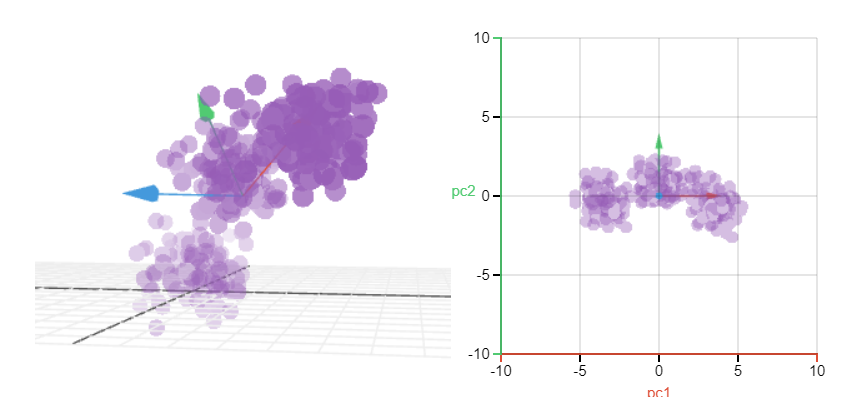

A PCA visualization showing the original data, the principal component directions, and the projection of observations onto the new axes is highly recommended here.

Try it here: https://setosa.io/ev/principal-component-analysis/

### Why do we standardize before PCA?

PCA is based on variation in the features.

If one feature has a much larger numerical scale than another, it can dominate the analysis.

For our penguins:

- bill measurements are in millimetres
- flipper length is in millimetres
- body mass is in grams

Therefore, we will standardize the features before applying PCA.

### PCA workflow

Our PCA workflow will therefore be:

**Original features → Standardization → PCA → Principal components**

In [ ]:
# TODO: Build a Pipeline with two steps: "scaler" (StandardScaler) and
# "pca" (PCA), so scaling always happens before PCA. Store it as
# `pca_pipeline`.

# TODO: Fit the pipeline on X and transform it, storing the result in `X_pca`.

# TODO: Check the shape of X_pca.

The transformed dataset still has four columns because we asked PCA to keep all components.

However, the components are now ordered according to how much variation they explain.

Let's examine that next.

In [ ]:
# TODO: Extract the fitted PCA step from the pipeline
# (pca_pipeline.named_steps["pca"]). Store it as `pca`.

# TODO: Store the explained_variance_ratio_ in a variable called
# `explained_variance`.

# TODO: Display it as a DataFrame with index ["PC1", "PC2", "PC3", "PC4"]
# and column "Explained variance".

In [ ]:
# TODO: Create a bar chart showing the proportion of variance explained
# by each principal component (PC1-PC4).
# Add axis labels and a title, then show the plot.

We can also look at the **cumulative explained variance**.

This tells us how much of the original variation is retained when we keep the first 1, 2, 3, ... components.

In [ ]:
# TODO: Compute the cumulative explained variance (running total across
# components) and store it as `cumulative_variance`.
# Hint: look at the .cumsum() method.

# TODO: Plot cumulative explained variance against the number of
# components as a line plot with markers. Add axis labels and a title,
# then show the plot.

If the first two components explain a large proportion of the total variance, we can use PC1 and PC2 as a two-dimensional representation of the original four-dimensional dataset.

This is one of the main uses of PCA:

> **Reduce the number of dimensions while retaining as much of the important variation as possible.**

### What do the principal components represent?

PCA does not simply select two of our original variables.

Instead, each principal component is a **linear combination of the original features**.

For example, PC1 may contain contributions from bill length, bill depth, flipper length, and body mass.

The coefficients used to construct each component are called **loadings**.

In [ ]:
# TODO: Build a DataFrame of PCA loadings called `loadings`: rows are
# the original features, columns are ["PC1", "PC2", "PC3", "PC4"], and
# values come from pca.components_ (transposed).

# TODO: Display the loadings.

The magnitude of a loading tells us how strongly a feature contributes to a component.

For example, a feature with a large absolute loading on PC1 contributes strongly to the direction represented by PC1.

The sign indicates the direction of the relationship, while the magnitude is more useful for comparing the relative contribution of features.

# 9. Visualizing the PCA representation

One of the most useful things about PCA is that it can make high-dimensional data easier to visualize.

Our original data has four dimensions.

We can now plot the first two principal components in a 2D graph.

In [ ]:
# TODO: Build a DataFrame `pca_df` containing just the first two
# principal components (columns "PC1", "PC2") from X_pca, keeping the
# same index as X.

# TODO: Add a "species" column from penguins_clean for interpretation
# only — remember species was NOT used to fit PCA.

# TODO: Display the first few rows.

In [ ]:
# TODO: Create a scatterplot of PC1 vs PC2, coloured by species
# (for interpretation only).

# TODO: Label the axes with the percentage of variance explained by
# each component (use `explained_variance`), add a title, then show.

Notice an important distinction:

We are showing `species` on the plot, but **species was not used to calculate PCA**.

We are using the known species labels only after the unsupervised transformation to help us interpret the structure that PCA found.

This is different from supervised learning, where the target labels are explicitly used during training.

# 10. K-means on PCA Components

We can now combine the two ideas from this tutorial.

Instead of clustering the original four-dimensional measurements, we can cluster the observations using their PCA representation.

For visualization, we will use the first two principal components.

In [ ]:
# TODO: Select just PC1 and PC2 from X_pca as `X_pca_2d`, so clustering
# matches the 2D visualization.

# TODO: Fit a KMeans model with 3 clusters on X_pca_2d (same
# hyperparameters as before). Store it as `kmeans_pca`.

# TODO: Store the cluster labels in `clusters_pca` and display the
# first 10.

In [ ]:
# TODO: Create a scatterplot of X_pca_2d, colouring points by
# `clusters_pca`.

# TODO: Overlay the fitted centroids (kmeans_pca.cluster_centers_) as
# large "X" markers, labelled "Centroids".

# TODO: Label the axes with variance explained, add a title and
# legend, then show the plot.

We have now combined both techniques:

**Standardization → PCA → K-means**

PCA gives us a compact representation of the data, while K-means finds groups within that representation.

The PCA plot also makes it easier to visualize the clusters because we have reduced the data from four dimensions to two.

# 11. Choosing the Number of Clusters

So far, we have used:

```python
n_clusters=3
```

because we know that the dataset contains three penguin species.

But in a real unsupervised learning problem, we usually do not know the correct number of clusters in advance.

Two common tools that can help us choose k are:

* the elbow method
* the silhouette score

# 12. Elbow method

### Elbow method

K-means provides a quantity called **inertia**.

Inertia measures the total squared distance between observations and the centroid of their assigned cluster.

Lower inertia means that observations are closer to their cluster centers.

However, inertia will almost always decrease as we increase the number of clusters.

We therefore look for an **elbow**: a point where adding additional clusters provides diminishing improvement.

In [ ]:
# TODO: For k = 1 through 10, fit a KMeans model on X_pca_2d and record
# its inertia_ (within-cluster sum of squares) in a list called
# `inertias`. Use the same hyperparameters as before for each model.

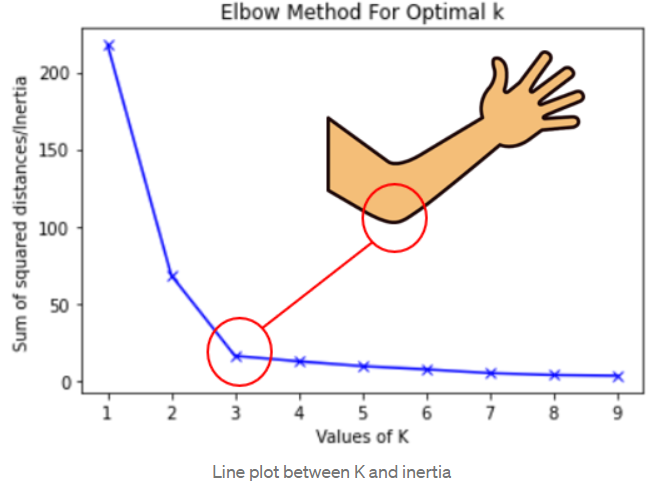

In [ ]:
# TODO: Plot `inertias` against k (1 through 10) as a line plot with
# markers. Add axis labels and a title ("Elbow Method"), then show.

### Silhouette score

Another useful measure is the **silhouette score**.

It considers both:

- how close an observation is to observations in its own cluster
- how far it is from observations in other clusters

The score ranges from approximately **-1 to 1**.

Higher values generally indicate better-separated and more compact clusters.

In [ ]:
# TODO: For k = 2 through 10 (silhouette score needs at least 2
# clusters), fit a KMeans model on X_pca_2d, get its predicted labels,
# and compute the silhouette_score. Store each score in a list called
# `silhouette_scores`.

In [ ]:
# TODO: Plot `silhouette_scores` against k (2 through 10) as a line
# plot with markers. Add axis labels and a title, then show.

# 12. Takeaways

In this tutorial, we introduced two unsupervised learning techniques and used them together.

### K-means

- Groups observations based on similarity.
- Uses distances to cluster centroids.
- Requires us to choose the number of clusters, `k`.
- Feature scaling is important when variables have different scales.

### PCA

- Creates new features called principal components.
- PC1 captures the largest amount of variation.
- Later components capture progressively less variation.
- Explained variance helps us decide how many components to keep.
- PCA can reduce dimensionality and make high-dimensional data easier to visualize.

### Putting them together

A common workflow is:

**Numerical features → Standardization → PCA → K-means**

Finally, remember that clustering is **unsupervised**. The algorithm does not know the true species labels. If we display species on our plots, we are using them only to interpret the discovered structure.